In [55]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats.mstats import winsorize
import pandas_datareader.data as web
import os
import re
import requests
import json
from datetime import datetime

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

## Risk Modeling for Bonds

Evaluate variation of the daily bond prices. Investigating if there are any bonds with low variation indicating that they are not frequently traded.
Using historical bond data to analyze and model risk factors affecting bond prices and yields.



In [56]:
# load the bond data
bond_data = pd.read_parquet('all_bonds_data.parquet')
bond_data.head()

,Date,price,bond,term
0,2021-09-27,99.883,United States Treasury Notes 0.25% 30-SEP-2023...,2
1,2021-09-28,99.887,United States Treasury Notes 0.25% 30-SEP-2023...,2
2,2021-09-29,99.902,United States Treasury Notes 0.25% 30-SEP-2023...,2
3,2021-09-30,99.918,United States Treasury Notes 0.25% 30-SEP-2023...,2
4,2021-10-01,99.969,United States Treasury Notes 0.25% 30-SEP-2023...,2


In [57]:
# calculate the log returns for each bond
bond_log_returns = []
for group, group_df in bond_data.groupby(['bond', 'term']):
    # sort the group by date
    group_df = group_df.sort_values(by='Date', ascending=True)
    # calculate the log returns
    group_df['log_return'] = np.log(group_df['price'] / group_df['price'].shift(1))
    bond_log_returns.append(group_df)

bond_log_returns = pd.concat(bond_log_returns)
bond_log_returns.head()

,Date,price,bond,term,log_return
498251,2021-02-22,101.816,Government of the United States of America 0.1...,30,NaN
498252,2021-02-23,101.245,Government of the United States of America 0.1...,30,-0.005624
498253,2021-02-24,100.311,Government of the United States of America 0.1...,30,-0.009268
498254,2021-02-25,97.719,Government of the United States of America 0.1...,30,-0.026179
498255,2021-02-26,101.223,Government of the United States of America 0.1...,30,0.035230


In [63]:
# get the variance of the log returns for each bond
counter = 0
rows = []
for group, group_df in bond_log_returns.groupby(['bond', 'term']):
    # calcaute the variance then store as a row
    variance = group_df['log_return'].var()
    # calcualte the IQR
    Q1 = group_df['log_return'].quantile(0.25)
    Q3 = group_df['log_return'].quantile(0.75)
    IQR = Q3 - Q1
    row = {
        'bond': group[0],
        'term': group[1],
        'variance': variance,
        'IQR': IQR
    }

    rows.append(row)

df_variance = pd.DataFrame(rows)
df_variance = df_variance.sort_values(by='variance', ascending=True)
df_variance.head()

,bond,term,variance,IQR
148,Government of the United States of America FRN...,2,3.940440e-09,0.00002
143,Government of the United States of America FRN...,2,4.737229e-09,0.00005
159,Government of the United States of America FRN...,2,5.092304e-09,0.00006
142,Government of the United States of America FRN...,2,5.175716e-09,0.00004
150,Government of the United States of America FRN...,2,5.248130e-09,0.00005


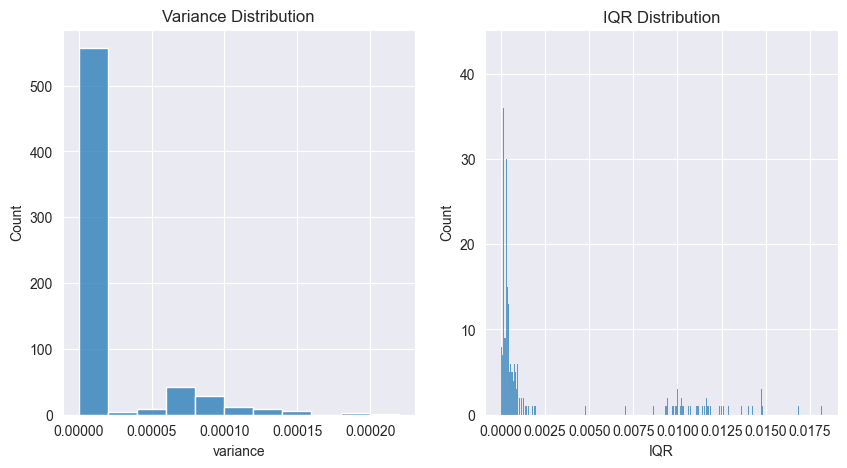

In [65]:
# plot the variance distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for i in range(2):
    if i == 0:
        sns.histplot(df_variance['variance'], binwidth=0.00002, ax=axes[i]).set_title('Variance Distribution')
    else:
        sns.histplot(df_variance['IQR'], binwidth=0.00002, ax=axes[i]).set_title('IQR Distribution')

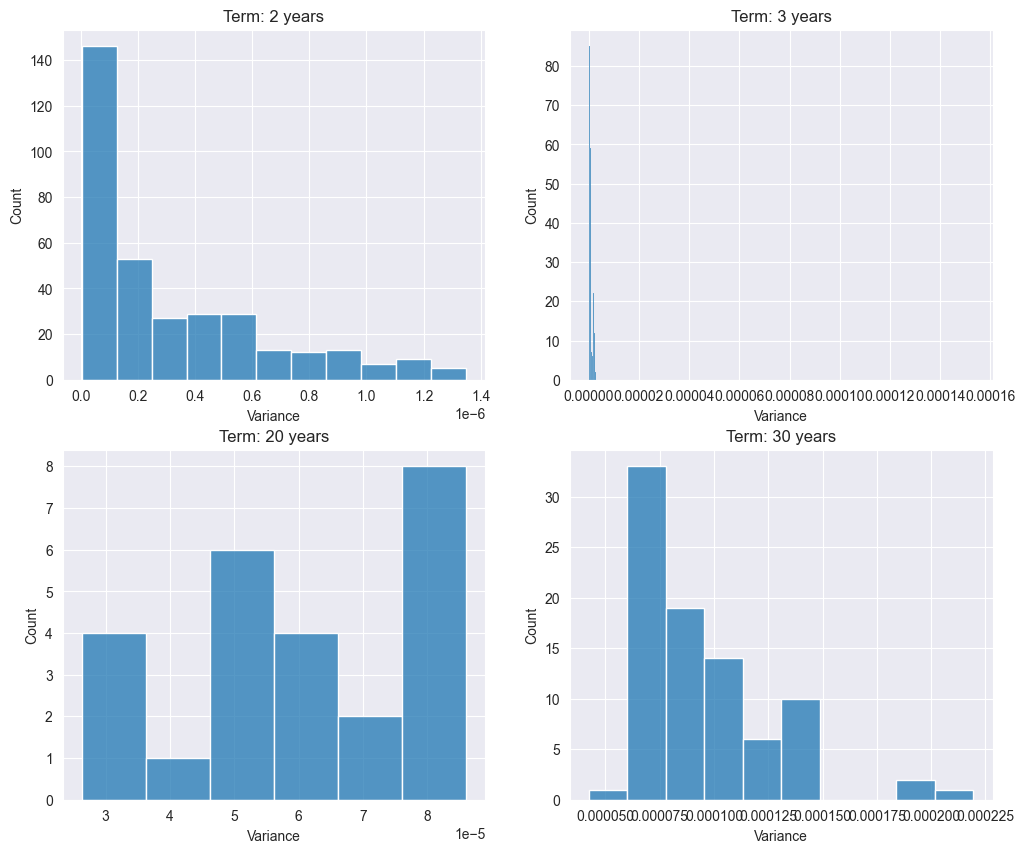

In [8]:
# lot the variance by term
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, term in enumerate(df_variance['term'].unique()):
    ax = axes[i]
    sns.histplot(df_variance[df_variance['term'] == term]['variance'], ax=ax)
    ax.set_title(f'Term: {term} years')
    ax.set_xlabel('Variance')
    ax.set_ylabel('Count')

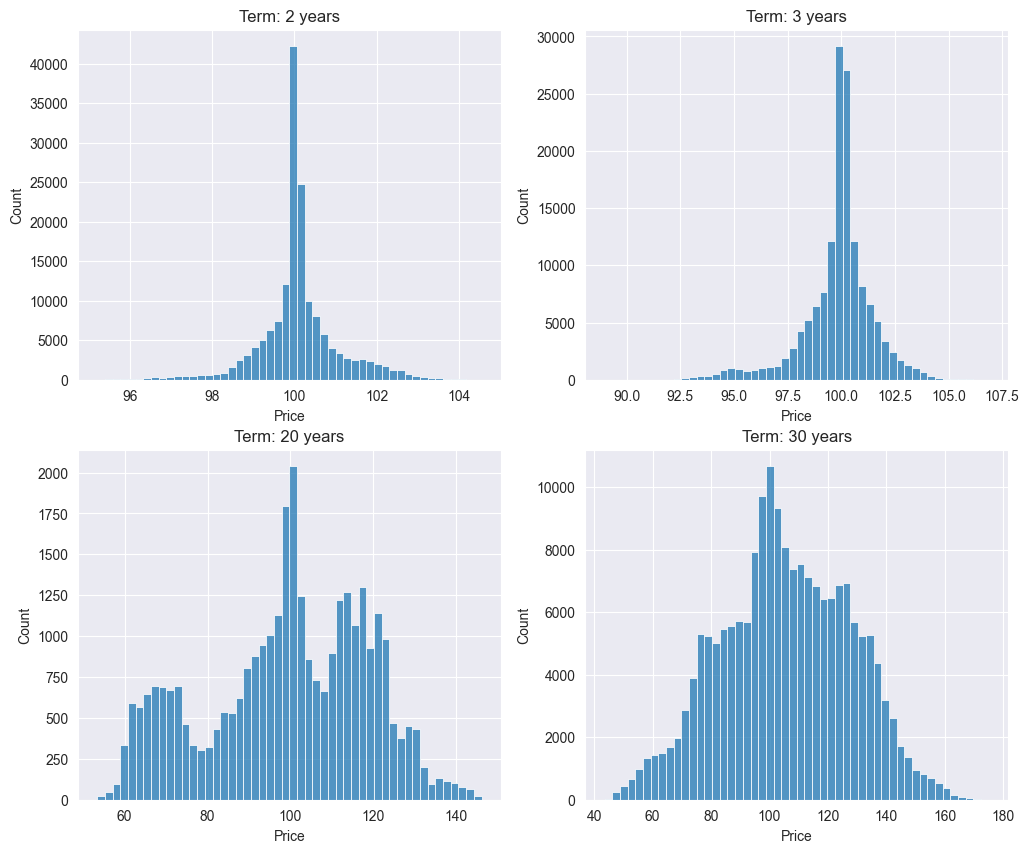

In [9]:
# get the distribution of prices by term
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, term in enumerate(bond_data['term'].unique()):
    ax = axes[i]
    sns.histplot(bond_data[bond_data['term'] == term]['price'], ax=ax, bins=50)
    ax.set_title(f'Term: {term} years')
    ax.set_xlabel('Price')
    ax.set_ylabel('Count')

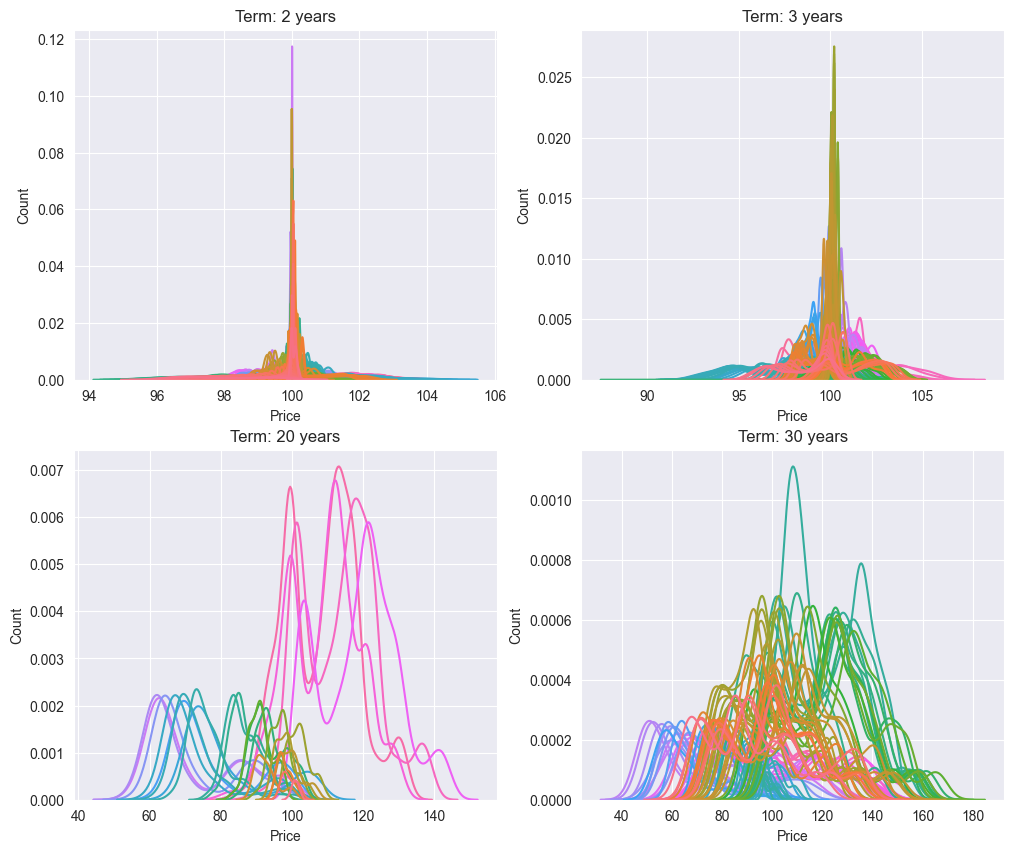

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, term in enumerate(bond_data['term'].unique()):
    ax = axes[i]
    sns.kdeplot(bond_data[bond_data['term'] == term], x='price', ax=ax, hue='bond', legend=False)
    ax.set_title(f'Term: {term} years')
    ax.set_xlabel('Price')
    ax.set_ylabel('Count')

In [66]:
# calculate the IQR for each bond
counter = 0
rows = []
for group, group_df in bond_log_returns.groupby(['bond', 'term']):
    # calcaute the variance then store as a row
    variance = group_df['price'].var()
    standard_dev = group_df['price'].std()
    mean = group_df['price'].mean()
    # calcualte the IQR
    Q1 = group_df['price'].quantile(0.25)
    Q3 = group_df['price'].quantile(0.75)
    IQR = Q3 - Q1
    row = {
        'bond': group[0],
        'term': group[1],
        'mean': mean,
        'std': standard_dev,
        'variance': variance,
        'IQR': IQR
    }

    rows.append(row)

df_moments = pd.DataFrame(rows)
df_moments = df_moments.sort_values(by='IQR', ascending=True)
df_moments.head()

,bond,term,mean,std,variance,IQR
140,Government of the United States of America FRN...,2,100.012688,0.014979,0.000224,0.01200
156,Government of the United States of America FRN...,2,100.011224,0.017098,0.000292,0.01725
148,Government of the United States of America FRN...,2,99.990030,0.015840,0.000251,0.02100
149,Government of the United States of America FRN...,2,100.010458,0.028990,0.000840,0.02175
667,United States Treasury Notes FRN 31-OCT-2022 (...,2,100.045455,0.029406,0.000865,0.03100


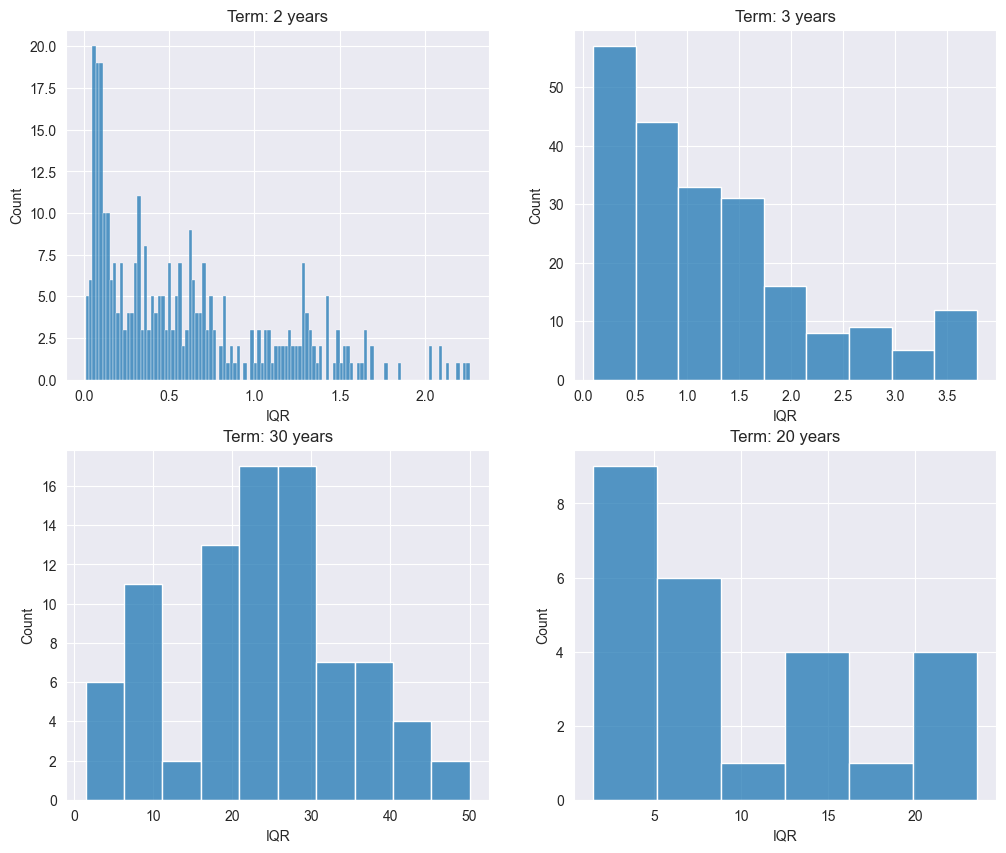

In [68]:
# plot the IQR distribution for each term
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, term in enumerate(df_moments['term'].unique()):
    ax = axes[i]
    if term == 2:
        sns.histplot(df_moments[df_moments['term'] == term]['IQR'], ax=ax, binwidth=0.02)
    else:
        sns.histplot(df_moments[df_moments['term'] == term]['IQR'], ax=ax)
    ax.set_title(f'Term: {term} years')
    ax.set_xlabel('IQR')
    ax.set_ylabel('Count')



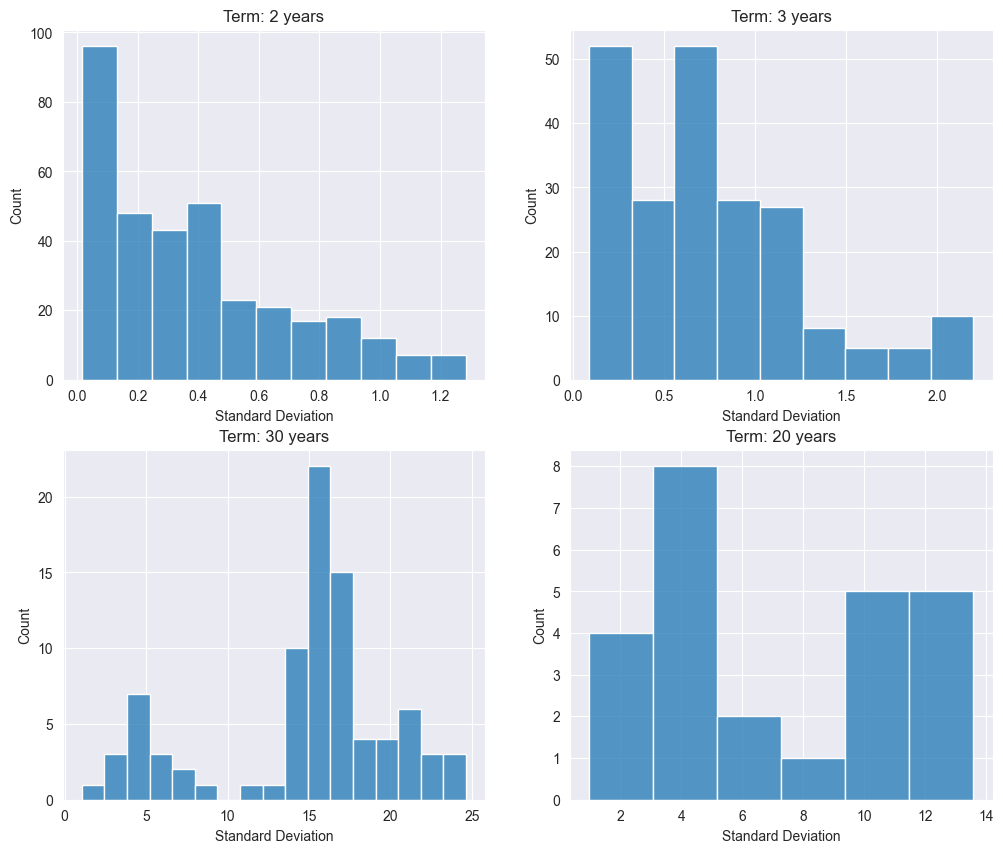

In [70]:
# get the variance of the windsorized prices

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, term in enumerate(df_moments['term'].unique()):
    ax = axes[i]
    sns.histplot(df_moments[df_moments['term'] == term]['std'], ax=ax)
    ax.set_title(f'Term: {term} years')
    ax.set_xlabel('Standard Deviation')
    ax.set_ylabel('Count')

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/3277975002.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/3277975002.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)


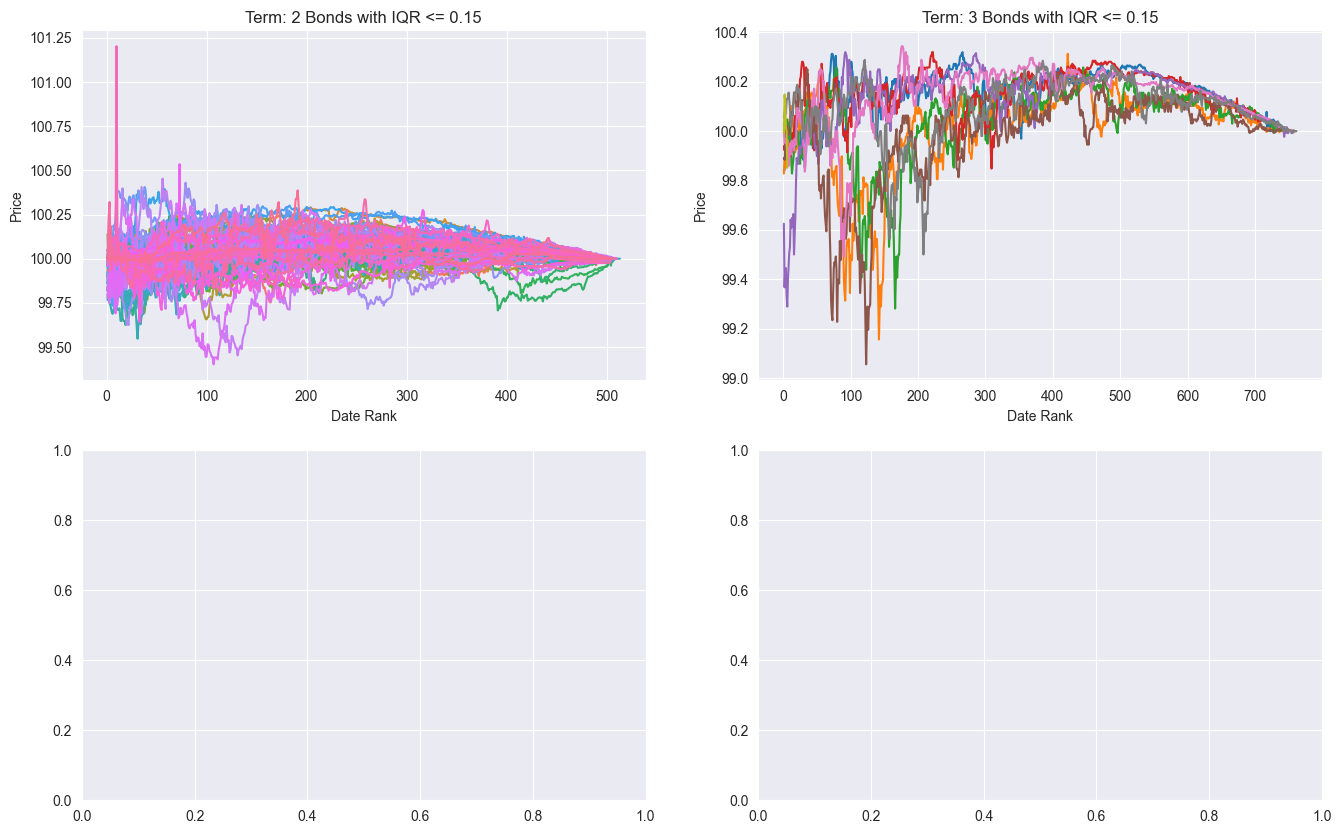

In [77]:
# filter the bonds with low variance
iqr_threshold = 0.15
low_variance_bonds = df_moments[df_moments['IQR'] <= iqr_threshold]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
i = 0

for group, group_df in low_variance_bonds.groupby('term'):
    # get the list of bonds
    bonds = group_df['bond'].tolist()
    # filter the winsorized dataframe
    df_filtered = bond_log_returns[(bond_log_returns['bond'].isin(bonds)) & (bond_log_returns['term'] == group)]
    # rank the dates by bond
    df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
    # plot the prices by bond
    # plot the
    sns.lineplot(data=df_filtered, x='date_rank', y='price', hue='bond', ax=axes[i], legend=False)
    axes[i].set_title(f'Term: {group} Bonds with IQR <= {iqr_threshold}')
    axes[i].set_xlabel('Date Rank')
    axes[i].set_ylabel('Price')
    i += 1


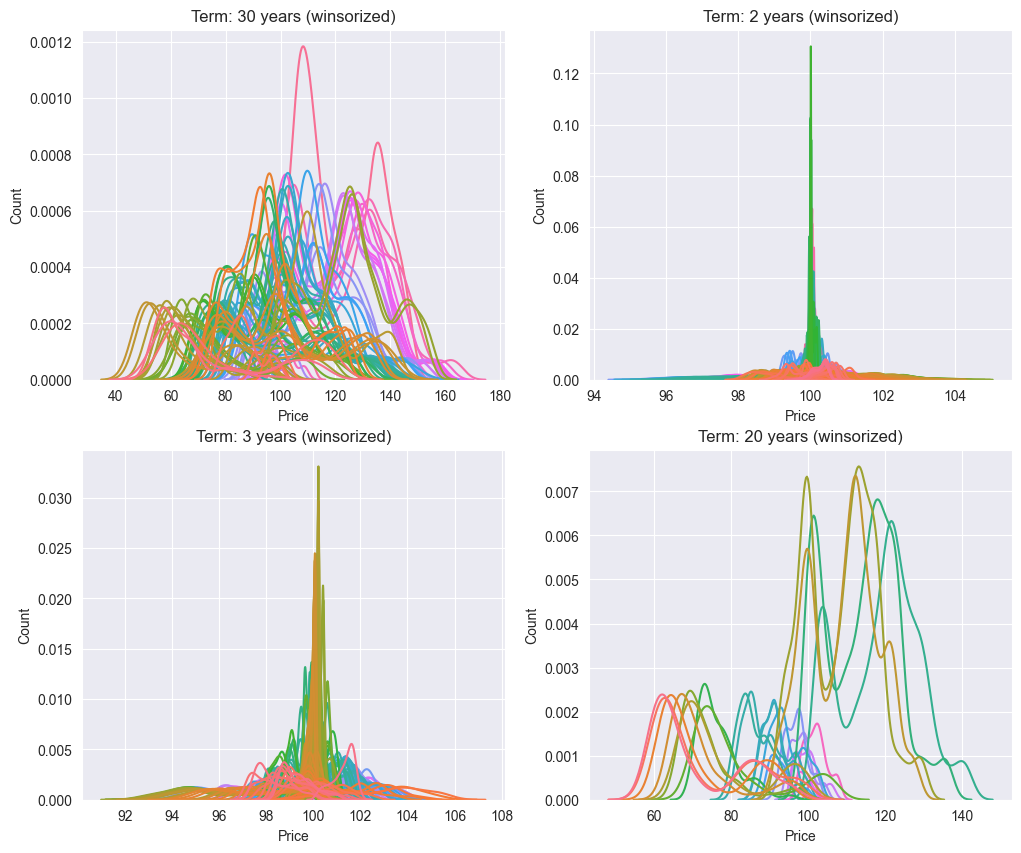

In [78]:
# get the percentiles for each bond
def percentile_filter(df: pd.DataFrame, col: str = 'price', percent: float = 0.95) -> pd.DataFrame:
    """
    Filter the dataframe to only include rows where the price is within the given percentage
    """
    df = df.sort_values(by=col, ascending=True)
    df['percentile'] = df[col].rank(pct=True)
    lower_bound = (1 - percent) / 2
    upper_bound = 1 - lower_bound
    return df[(df['percentile'] >= lower_bound) & (df['percentile'] <= upper_bound)]


# Calculate the windsorized variance for each bond
dfs = []
for group, group_df in bond_data.groupby(['bond', 'term']):
    group_df = group_df.sort_values(by='Date', ascending=True)
    df_tmp = percentile_filter(group_df, col='price', percent=0.95)
    dfs.append(df_tmp)

df_winsorized = pd.concat(dfs)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, term in enumerate(df_winsorized['term'].unique()):
    ax = axes[i]
    sns.kdeplot(df_winsorized[df_winsorized['term'] == term], x='price', ax=ax, hue='bond', legend=False)
    ax.set_title(f'Term: {term} years (winsorized)')
    ax.set_xlabel('Price')
    ax.set_ylabel('Count')

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/84243886.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/84243886.py:40: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)


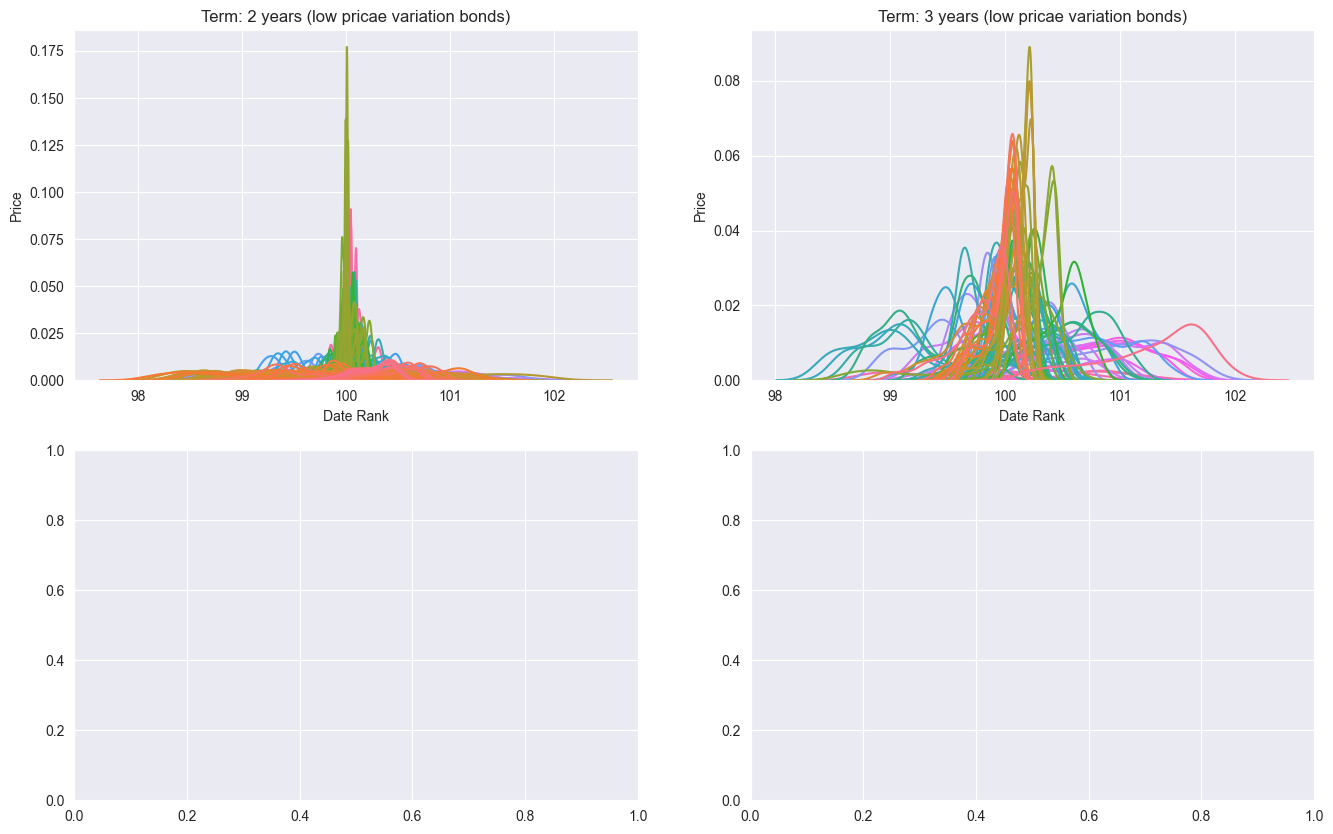

In [79]:
counter = 0
rows = []
for group, group_df in df_winsorized.groupby(['bond', 'term']):
    # calcaute the variance then store as a row
    variance = group_df['price'].var()
    standard_dev = group_df['price'].std()
    mean = group_df['price'].mean()
    # calcualte the IQR
    Q1 = group_df['price'].quantile(0.25)
    Q3 = group_df['price'].quantile(0.75)
    IQR = Q3 - Q1
    row = {
        'bond': group[0],
        'term': group[1],
        'mean': mean,
        'std': standard_dev,
        'variance': variance,
        'IQR': IQR
    }

    rows.append(row)

df_moments2 = pd.DataFrame(rows)
df_moments2 = df_moments2.sort_values(by='IQR', ascending=True)

std_threshold = 0.5

low_variance_bonds = df_moments2[df_moments2['std'] <= std_threshold]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
i = 0

for group, group_df in low_variance_bonds.groupby('term'):
    # get the list of bonds
    bonds = group_df['bond'].tolist()
    # filter the winsorized dataframe
    df_filtered = df_winsorized[(df_winsorized['bond'].isin(bonds)) & (df_winsorized['term'] == group)]
    # rank the dates by bond
    df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
    df_variance_filtered_dfs.append(df_filtered)
    # plot the prices by bond
    # plot the
    sns.kdeplot(data=df_filtered, x='price', hue='bond', ax=axes[i], legend=False)
    axes[i].set_title(f'Term: {group} years (low pricae variation bonds)')
    axes[i].set_xlabel('Date Rank')
    axes[i].set_ylabel('Price')
    i += 1

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/3332973606.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/3332973606.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/3332973606.py:14: Set

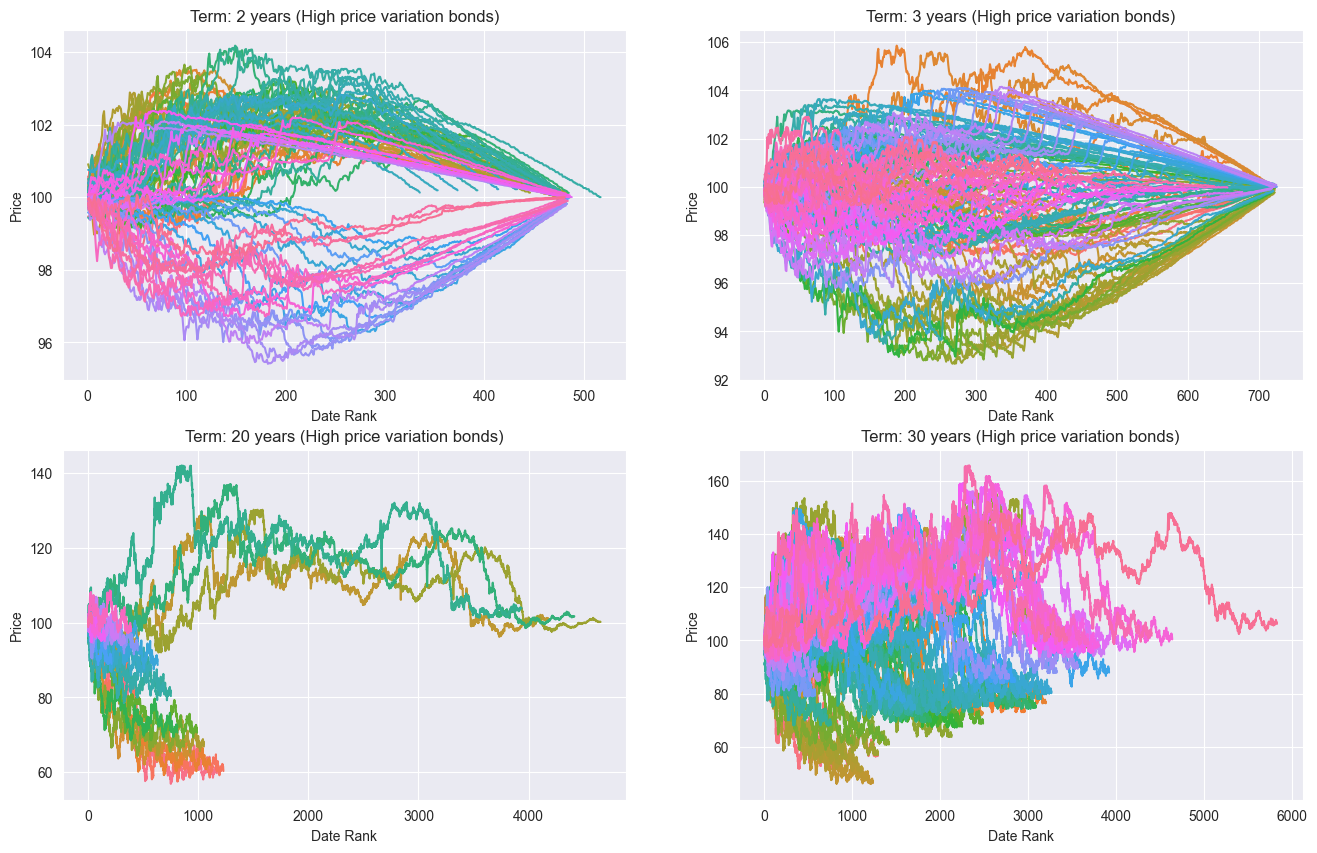

In [80]:
std_threshold = 0.5
high_variance_bonds = df_moments2[df_moments2['std'] > std_threshold]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
i = 0
df_variance_filtered_dfs = []
for group, group_df in high_variance_bonds.groupby('term'):
    # get the list of bonds
    bonds = group_df['bond'].tolist()
    # filter the winsorized dataframe
    df_filtered = df_winsorized[(df_winsorized['bond'].isin(bonds)) & (df_winsorized['term'] == group)]
    # rank the dates by bond
    df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
    df_variance_filtered_dfs.append(df_filtered)
    # plot the prices by bond
    # plot the
    sns.lineplot(data=df_filtered, x='date_rank', y='price', hue='bond', ax=axes[i], legend=False)
    axes[i].set_title(f'Term: {group} years (High price variation bonds)')
    axes[i].set_xlabel('Date Rank')
    axes[i].set_ylabel('Price')
    i += 1

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/3688840081.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/3688840081.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/3688840081.py:11: Set

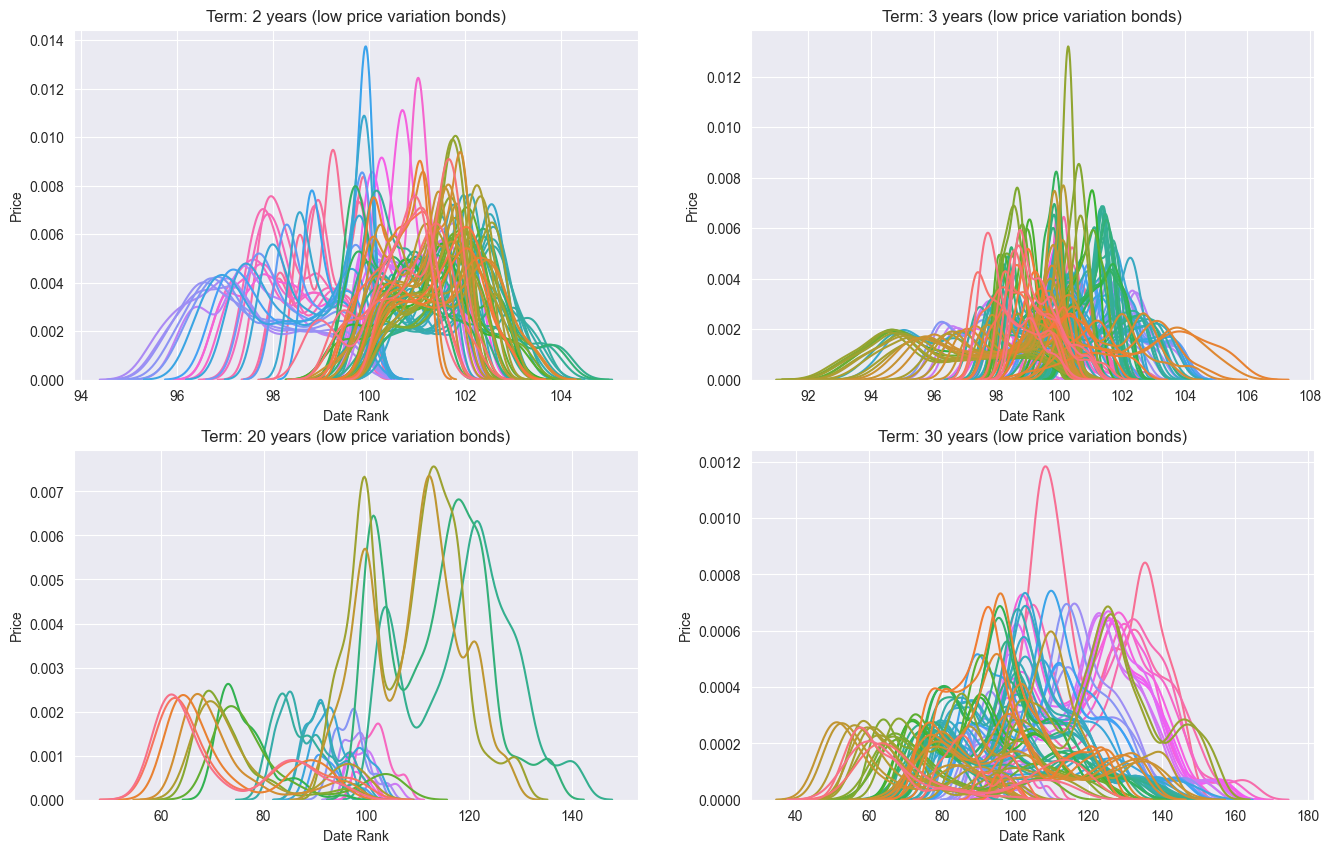

In [51]:
      fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()
i = 0
df_variance_filtered_dfs = []
for group, group_df in low_variance_bonds.groupby('term'):
    # get the list of bonds
    bonds = group_df['bond'].tolist()
    # filter the winsorized dataframe
    df_filtered = df_winsorized[(df_winsorized['bond'].isin(bonds)) & (df_winsorized['term'] == group)]
    # rank the dates by bond
    df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
    df_variance_filtered_dfs.append(df_filtered)
    # plot the prices by bond
    # plot the
    sns.kdeplot(data=df_filtered, x='price', hue='bond', ax=axes[i], legend=False)
    axes[i].set_title(f'Term: {group} years (low price variation bonds)')
    axes[i].set_xlabel('Date Rank')
    axes[i].set_ylabel('Price')
    i += 1

In [53]:
rows = []
for group, group_df in df_variance.groupby('term'):
    # get the list of bonds
    percentage = group_df[group_df['std'] > std_threshold].shape[0] / group_df.shape[0]
    row = {
        'term': group,
        'num_bonds': group_df.shape[0],
        'num_low_variance_bonds': group_df[group_df['std'] > std_threshold].shape[0],
        'percentage_higher_variance_bonds': percentage
    }
    rows.append(row)
df_rows = pd.DataFrame(rows)
df_rows


,term,num_bonds,num_low_variance_bonds,percentage_higher_variance_bonds
0,2,343,87,0.253644
1,3,215,134,0.623256
2,20,25,25,1.000000
3,30,86,86,1.000000


In [54]:
for group, group_df in low_variance_bonds.groupby('term'):
    # get the list of bonds
    bonds = group_df['bond'].tolist()
    # filter the winsorized dataframe
    df_filtered = df_winsorized[(df_winsorized['bond'].isin(bonds)) & (df_winsorized['term'] == group)]
    # rank the dates by bond
    df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)
    df_variance_filtered_dfs.append(df_filtered)
    # plot the prices by bond
    # plot the
    sns.lineplot(data=df_filtered, x='Date', y='price', hue='bond', ax=axes[i], legend=False)
    axes[i].set_title(f'Term: {group} years (higher price variation bonds)')
    axes[i].set_xlabel('Date Rank')
    axes[i].set_ylabel('Price')
    i += 1

/var/folders/h3/n4kr77l914l79rj692skv4jw0000gn/T/ipykernel_59737/2435233807.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['date_rank'] = df_filtered.groupby('bond')['Date'].rank(ascending=True)


IndexError: index 4 is out of bounds for axis 0 with size 4